In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")


In [6]:
orders['order_id'] = orders['order_id'].astype(str).str.strip()
items['order_id'] = items['order_id'].astype(str).str.strip()
items['product_id'] = items['product_id'].astype(str).str.strip()
products['product_id'] = products['product_id'].astype(str).str.strip()

orders['order_status'] = (
    orders['order_status']
    .astype(str)
    .str.strip()
    .str.lower()
)


In [9]:
merged = pd.merge(
    items,
    orders[['order_id', 'order_status']],
    on='order_id',
    how='left'
)


In [11]:
merged['item_revenue'] = merged['price'] + merged['freight_value']

merged['earned_revenue'] = merged['item_revenue'].where(
    merged['order_status'] == 'delivered',
    0
)

merged['leaked_revenue'] = merged['item_revenue'] - merged['earned_revenue']


In [13]:
gross_revenue = merged['item_revenue'].sum()
net_revenue = merged['earned_revenue'].sum()
revenue_leakage = gross_revenue - net_revenue

print("Gross Revenue:", round(gross_revenue, 2))
print("Net Revenue:", round(net_revenue, 2))
print("Revenue Leakage:", round(revenue_leakage, 2))


Gross Revenue: 15843553.24
Net Revenue: 15419773.75
Revenue Leakage: 423779.49


In [15]:
merged = pd.merge(
    merged,
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)


In [17]:
leakage_by_category = (
    merged.groupby('product_category_name')['leaked_revenue']
    .sum()
    .sort_values(ascending=False)
)

print("\nTop 10 Categories by Leakage:")
print(leakage_by_category.head(10))


KeyError: 'product_category_name'

In [20]:
merged['product_category_name'] = merged['product_category_name_y']


In [33]:
merged = merged.drop(
    columns=['product_category_name_x','product_category_name_y']
)


KeyError: "['product_category_name_x', 'product_category_name_y'] not found in axis"

In [34]:
category_summary = (
    merged.groupby('product_category_name')
    .agg(
        gross_revenue=('item_revenue', 'sum'),
        leaked_revenue=('leaked_revenue', 'sum')
    )
)

category_summary['leakage_percent'] = (
    category_summary['leaked_revenue'] /
    category_summary['gross_revenue']
) * 100


In [25]:
leakage_by_category = (
    merged.groupby('product_category_name')['leaked_revenue']
    .sum()
    .sort_values(ascending=False)
)

leakage_by_category.head(10)


product_category_name
relogios_presentes        41208.49
esporte_lazer             38399.57
beleza_saude              29158.54
cool_stuff                27649.06
informatica_acessorios    26548.63
moveis_decoracao          22181.87
utilidades_domesticas     20005.52
ferramentas_jardim        17073.53
cama_mesa_banho           16472.46
automotivo                15929.57
Name: leaked_revenue, dtype: float64

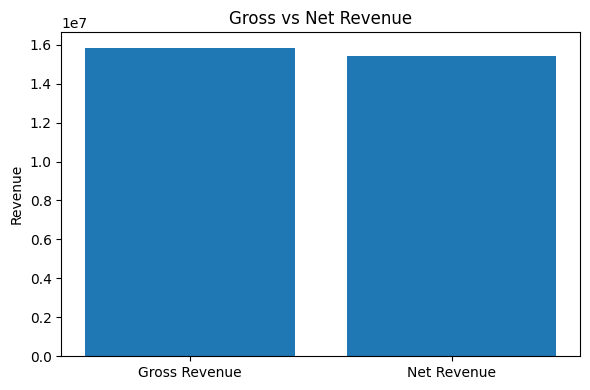

In [27]:
plt.figure(figsize=(6,4))
plt.bar(['Gross Revenue', 'Net Revenue'], [gross_revenue, net_revenue])
plt.title("Gross vs Net Revenue")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


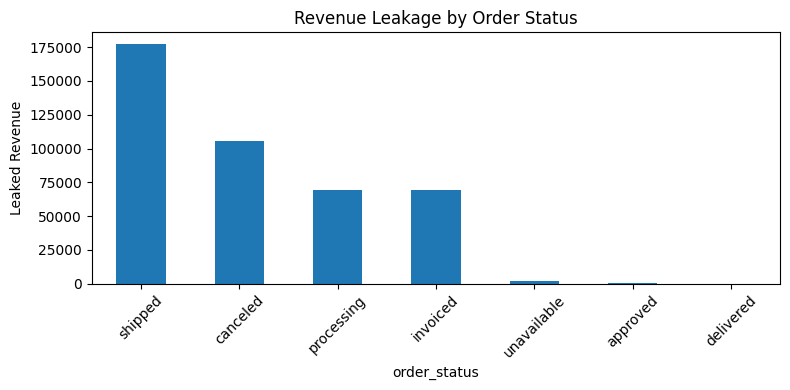

In [29]:
leakage_status = (
    merged.groupby('order_status')['leaked_revenue']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,4))
leakage_status.plot(kind='bar')
plt.title("Revenue Leakage by Order Status")
plt.ylabel("Leaked Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


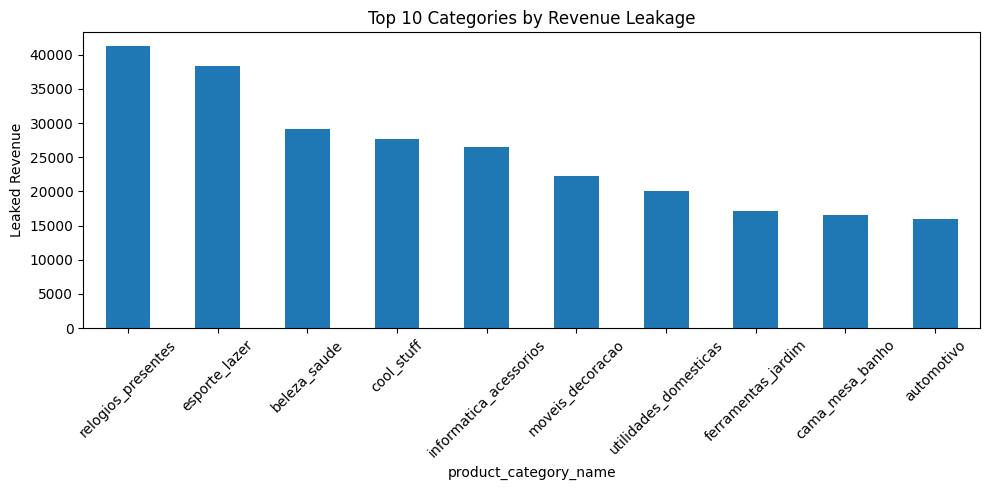

In [31]:
plt.figure(figsize=(10,5))
leakage_by_category.head(10).plot(kind='bar')
plt.title("Top 10 Categories by Revenue Leakage")
plt.ylabel("Leaked Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


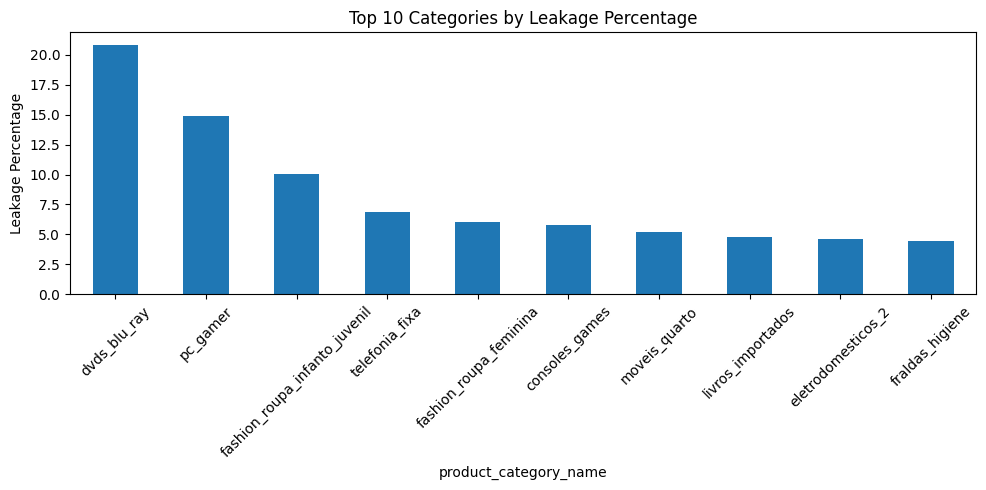

In [35]:
plt.figure(figsize=(10,5))
category_summary.sort_values(
    'leakage_percent',
    ascending=False
).head(10)['leakage_percent'].plot(kind='bar')

plt.title("Top 10 Categories by Leakage Percentage")
plt.ylabel("Leakage Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
